**Mount drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

base_path = "/content/drive/MyDrive/GTSRB"
print(os.listdir(base_path))

['archive.zip']


**Unzip Dataset**

In [3]:
!unzip "/content/drive/MyDrive/GTSRB/archive.zip" -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/5/00005_00053_00010.png  
  inflating: /content/train/5/00005_00053_00011.png  
  inflating: /content/train/5/00005_00053_00012.png  
  inflating: /content/train/5/00005_00053_00013.png  
  inflating: /content/train/5/00005_00053_00014.png  
  inflating: /content/train/5/00005_00053_00015.png  
  inflating: /content/train/5/00005_00053_00016.png  
  inflating: /content/train/5/00005_00053_00017.png  
  inflating: /content/train/5/00005_00053_00018.png  
  inflating: /content/train/5/00005_00053_00019.png  
  inflating: /content/train/5/00005_00053_00020.png  
  inflating: /content/train/5/00005_00053_00021.png  
  inflating: /content/train/5/00005_00053_00022.png  
  inflating: /content/train/5/00005_00053_00023.png  
  inflating: /content/train/5/00005_00053_00024.png  
  inflating: /content/train/5/00005_00053_00025.png  
  inflating: /content/train/5/00005_00053_00026.png  
  inflating: /content/train/5/0

In [4]:
import os

print(os.listdir("/content"))


['.config', 'Meta', 'Test.csv', 'meta', 'Train', 'Meta.csv', 'Train.csv', 'Test', 'train', 'drive', 'test', 'sample_data']


In [5]:
DATA_ROOT = "/content"


In [6]:
import os
import pandas as pd
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

In [7]:
class GTSRBThreeClassDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(
            self.root_dir,
            row["Path"].replace("Train", "train").replace("Test", "test")
        )

        image = Image.open(img_path).convert("RGB")
        label = int(row["NewLabel"])

        if self.transform:
            image = self.transform(image)

        return image, label

    def __len__(self):
        return len(self.df)

**Dataset loading CVS files**

In [8]:
import pandas as pd

train_df = pd.read_csv("/content/Train.csv")
test_df  = pd.read_csv("/content/Test.csv")

**Label mapping**

In [9]:
# Define categories
circle_classes = [0,1,2,3,4,5,7,8,9,10,15,16,17]
triangle_classes = [11,13,18,19,20,21,22,23,24,25,26,27,28,29,30,31]
blue_classes = [33,34,35,36,37,38,39,40]

label_map = {}

for c in circle_classes:
    label_map[c] = 0
for c in triangle_classes:
    label_map[c] = 1
for c in blue_classes:
    label_map[c] = 2

def remap(df):
    df = df[df["ClassId"].isin(label_map.keys())].copy()
    df["NewLabel"] = df["ClassId"].map(label_map)
    return df

train_df = remap(train_df)
test_df = remap(test_df)

In [10]:
train_dataset = GTSRBThreeClassDataset(train_df, "/content")
test_dataset  = GTSRBThreeClassDataset(test_df, "/content")

**DataSet Class**

In [11]:
img, label = train_dataset[0]
print(label)
img

1


**Transform**


In [12]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.10, 0.10)
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

**Recreate dataset with transforms**

In [13]:
train_dataset = GTSRBThreeClassDataset(train_df, "/content", transform=train_transform)
test_dataset  = GTSRBThreeClassDataset(test_df, "/content", transform=test_transform)

**DataLoader**

In [14]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

**Testing**

In [15]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)
print(labels[:10])

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([0, 1, 1, 2, 2, 0, 1, 2, 0, 0])


 **Set Device**

In [16]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


**Testing if GPU is On**

In [17]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


**Load Pretrained ResNet18**

In [18]:
import torch.nn as nn
from torchvision import models

# Use ResNet18 (faster)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)

# Move to GPU
model = model.to(device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s]


Linear(in_features=512, out_features=3, bias=True)


**Loss and Optimizer**

In [19]:
import torch.optim as optim

learning_rate = 1e-4
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=learning_rate)


**Training loop**

In [20]:
num_epochs = 3

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if batch_idx % 20 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Batch {batch_idx}/{len(train_loader)}")

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

Epoch 1/3, Batch 0/1100
Epoch 1/3, Batch 20/1100
Epoch 1/3, Batch 40/1100
Epoch 1/3, Batch 60/1100
Epoch 1/3, Batch 80/1100
Epoch 1/3, Batch 100/1100
Epoch 1/3, Batch 120/1100
Epoch 1/3, Batch 140/1100
Epoch 1/3, Batch 160/1100
Epoch 1/3, Batch 180/1100
Epoch 1/3, Batch 200/1100
Epoch 1/3, Batch 220/1100
Epoch 1/3, Batch 240/1100
Epoch 1/3, Batch 260/1100
Epoch 1/3, Batch 280/1100
Epoch 1/3, Batch 300/1100
Epoch 1/3, Batch 320/1100
Epoch 1/3, Batch 340/1100
Epoch 1/3, Batch 360/1100
Epoch 1/3, Batch 380/1100
Epoch 1/3, Batch 400/1100
Epoch 1/3, Batch 420/1100
Epoch 1/3, Batch 440/1100
Epoch 1/3, Batch 460/1100
Epoch 1/3, Batch 480/1100
Epoch 1/3, Batch 500/1100
Epoch 1/3, Batch 520/1100
Epoch 1/3, Batch 540/1100
Epoch 1/3, Batch 560/1100
Epoch 1/3, Batch 580/1100
Epoch 1/3, Batch 600/1100
Epoch 1/3, Batch 620/1100
Epoch 1/3, Batch 640/1100
Epoch 1/3, Batch 660/1100
Epoch 1/3, Batch 680/1100
Epoch 1/3, Batch 700/1100
Epoch 1/3, Batch 720/1100
Epoch 1/3, Batch 740/1100
Epoch 1/3, Batch 7

**Test Accuracy**

In [21]:
from sklearn.metrics import accuracy_score

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.9760389036251105


**Confusion Matrix**

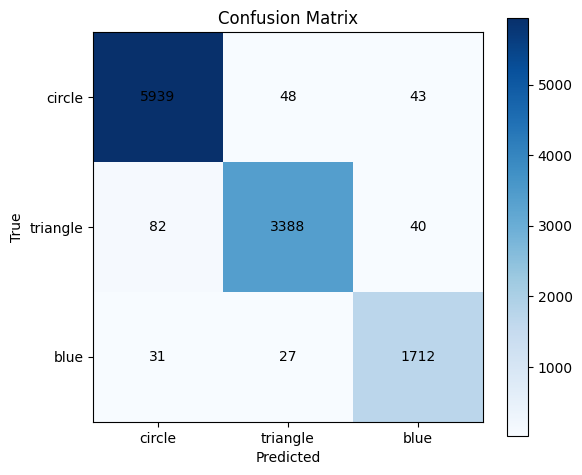

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1,2], ["circle", "triangle", "blue"])
plt.yticks([0,1,2], ["circle", "triangle", "blue"])
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

**Training Curves**

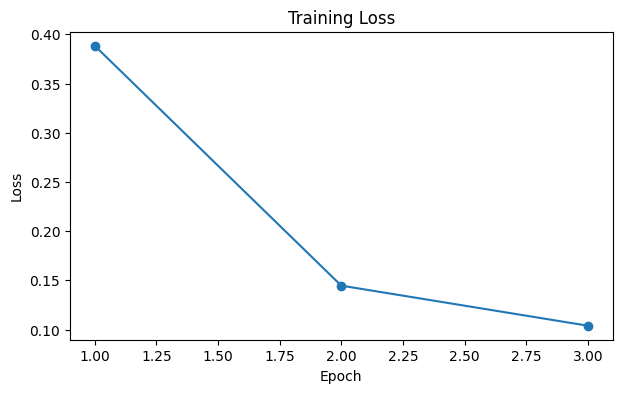

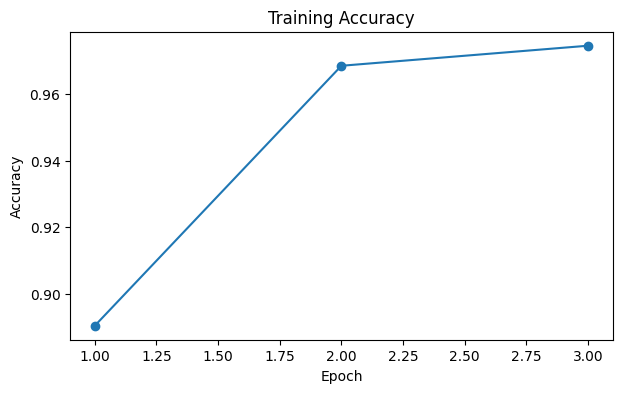

In [23]:
plt.figure(figsize=(7,4))
plt.plot(range(1, num_epochs+1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(range(1, num_epochs+1), train_accuracies, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()